# WildScan – CNN1: Kingdom Classifier
Classifies images into Fungi, Animalia (Amphibia, Arachnida, Insecta, Mammalia, Reptilia) classes.
This is the first model in the WildScan pipeline.

## 1. Setup

In [1]:
import os, shutil, time, random
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile, UnidentifiedImageError
from io import BytesIO

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix

# Allow truncated images to load
ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Build Dataset from inat_images

In [3]:
SOURCE_DIR = '/content/drive/MyDrive/inat_images'
CNN1_DIR = './data/cnn1'

# Copy images into subfolders by class (from filename label)
for fname in os.listdir(SOURCE_DIR):
    if not fname.endswith('.jpg'):
        continue
    parts = fname.split('_')
    if len(parts) < 2:
        continue
    label = parts[1]
    dst_dir = os.path.join(CNN1_DIR, label)
    os.makedirs(dst_dir, exist_ok=True)
    dst = os.path.join(dst_dir, fname)
    try:
        shutil.copy(os.path.join(SOURCE_DIR, fname), dst)
        Image.open(dst).verify()  # remove corrupted on copy
    except Exception:
        if os.path.exists(dst):
            os.remove(dst)

print('Done! Folder counts:')
for cls in sorted(os.listdir(CNN1_DIR)):
    print(f'  {cls}: {len(os.listdir(os.path.join(CNN1_DIR, cls)))} images')

Done! Folder counts:
  Amphibia: 421 images
  Arachnida: 870 images
  Fungi: 7670 images
  Insecta: 7281 images
  Mammalia: 817 images
  Reptilia: 106 images


In [4]:
# Add Plantae from plants_class Drive folder
import os, shutil
from PIL import Image

PLANTS_SOURCE = '/content/drive/MyDrive/plants_class'
PLANTAE_DIR = './data/cnn1/Plantae'
TARGET = 500

os.makedirs(PLANTAE_DIR, exist_ok=True)

# Grab images from all plant class subfolders
count = 0
for cls_folder in os.listdir(PLANTS_SOURCE):
    if count >= TARGET:
        break
    cls_path = os.path.join(PLANTS_SOURCE, cls_folder)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if count >= TARGET:
            break
        src = os.path.join(cls_path, fname)
        dst = os.path.join(PLANTAE_DIR, f'{count:05d}.jpg')
        try:
            img = Image.open(src).convert('RGB')
            img.save(dst)
            count += 1
        except Exception:
            continue

print(f'Plantae: {len(os.listdir(PLANTAE_DIR))} images added')

Plantae: 500 images added


## 4. Balance Dataset

In [5]:
TARGET = 500

# Cap overrepresented classes
for cls in os.listdir(CNN1_DIR):
    folder = os.path.join(CNN1_DIR, cls)
    imgs = os.listdir(folder)
    if len(imgs) > TARGET:
        random.shuffle(imgs)
        for img in imgs[TARGET:]:
            os.remove(os.path.join(folder, img))
        print(f'{cls}: capped to {TARGET}')

# Top up underrepresented classes from iNaturalist
TAXON_IDS = {'Reptilia': 26036, 'Amphibia': 20978}

for class_name, taxon_id in TAXON_IDS.items():
    folder = os.path.join(CNN1_DIR, class_name)
    os.makedirs(folder, exist_ok=True)
    current = len(os.listdir(folder))
    needed = TARGET - current
    if needed <= 0:
        print(f'{class_name}: already at {current}, skipping')
        continue
    print(f'{class_name}: has {current}, fetching {needed} more...')
    fetched, page = 0, 1
    while fetched < needed and page <= 100:
        try:
            response = requests.get(
                'https://api.inaturalist.org/v1/observations',
                params={'taxon_id': taxon_id, 'quality_grade': 'research',
                        'photos': True, 'per_page': 100, 'page': page, 'order_by': 'id'},
                timeout=10
            ).json()
            for obs in response.get('results', []):
                if fetched >= needed:
                    break
                try:
                    photo_url = obs['photos'][0]['url'].replace('square', 'medium')
                    img_data = requests.get(photo_url, timeout=10).content
                    img = Image.open(BytesIO(img_data)).convert('RGB')
                    count = len(os.listdir(folder))
                    img.save(os.path.join(folder, f'{count:05d}.jpg'))
                    fetched += 1
                except Exception:
                    continue
            page += 1
            time.sleep(1)
        except Exception:
            time.sleep(5)
            page += 1
    print(f'  Done! {class_name} now has {len(os.listdir(folder))} images')

print('\nFinal counts:')
for cls in sorted(os.listdir(CNN1_DIR)):
    print(f'  {cls}: {len(os.listdir(os.path.join(CNN1_DIR, cls)))} images')

Insecta: capped to 500
Mammalia: capped to 500
Arachnida: capped to 500
Fungi: capped to 500
Reptilia: has 106, fetching 394 more...
  Done! Reptilia now has 500 images
Amphibia: has 421, fetching 79 more...
  Done! Amphibia now has 500 images

Final counts:
  Amphibia: 500 images
  Arachnida: 500 images
  Fungi: 500 images
  Insecta: 500 images
  Mammalia: 500 images
  Plantae: 500 images
  Reptilia: 500 images


## 5. EDA

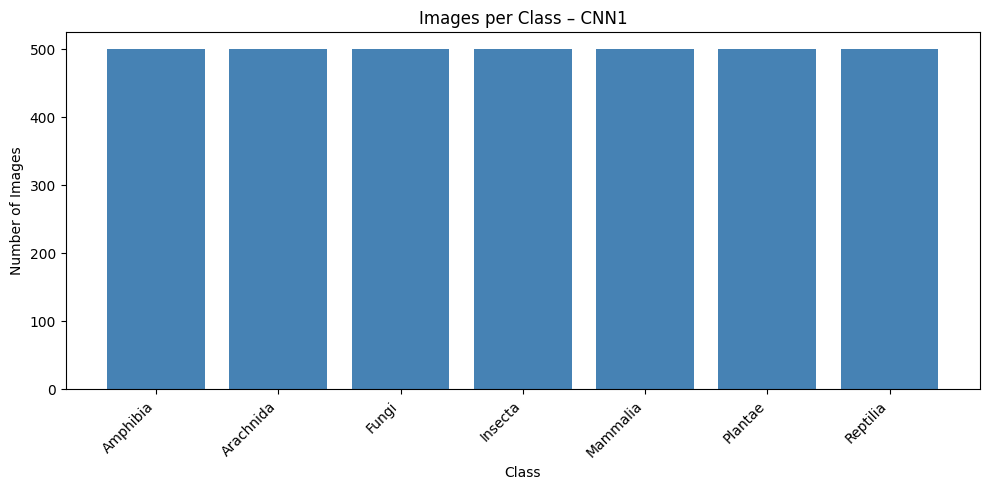

Total: 3500


In [6]:
classes = sorted(os.listdir(CNN1_DIR))
class_counts = {cls: len(os.listdir(os.path.join(CNN1_DIR, cls))) for cls in classes}

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Images per Class – CNN1')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Total:', sum(class_counts.values()))

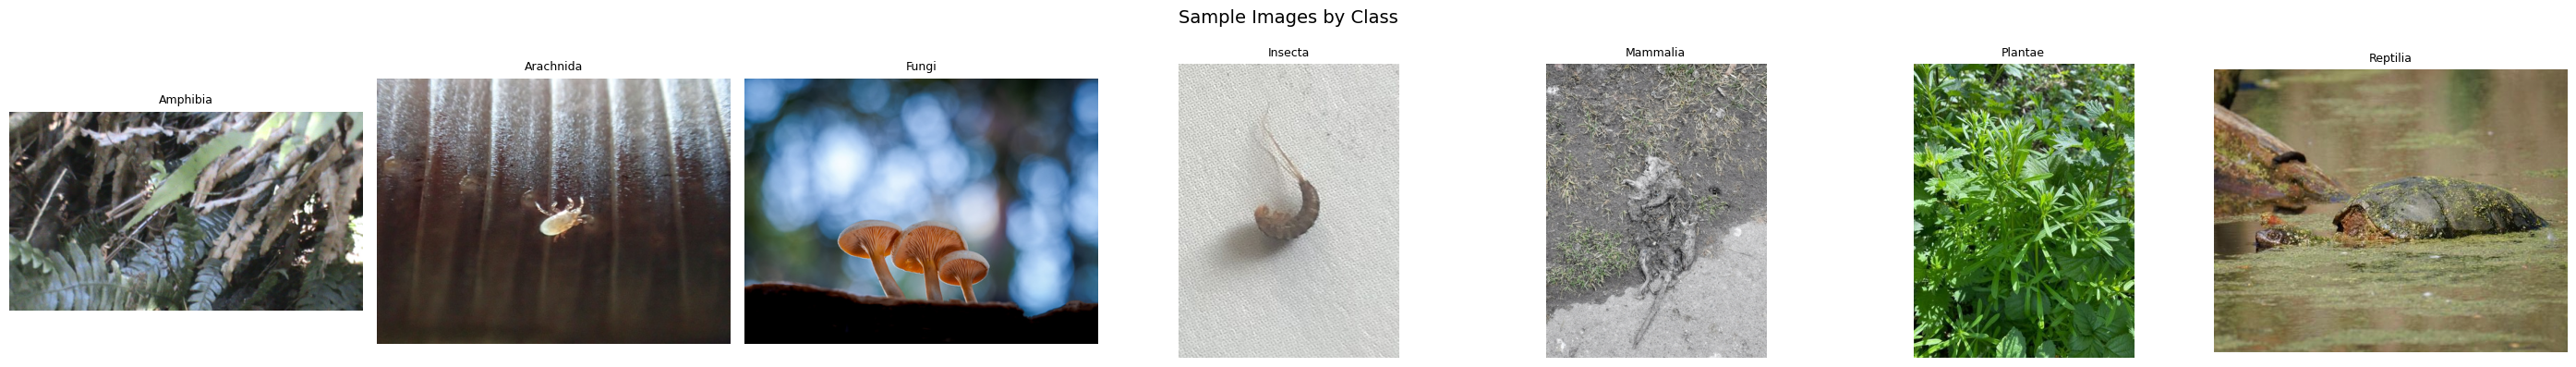

In [7]:
# Sample images per class
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
for ax, cls in zip(axes, classes):
    cls_path = os.path.join(CNN1_DIR, cls)
    img = Image.open(os.path.join(cls_path, os.listdir(cls_path)[0])).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images by Class', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Preprocessing & DataLoaders

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_dataset = ImageFolder(root=CNN1_DIR, transform=None)
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES = len(class_to_idx)
print('Classes:', class_to_idx)
print(f'Total samples: {len(full_dataset)}')

total = len(full_dataset)
train_size = int(0.90 * total)
val_size   = int(0.05 * total)
test_size  = total - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

Classes: {'Amphibia': 0, 'Arachnida': 1, 'Fungi': 2, 'Insecta': 3, 'Mammalia': 4, 'Plantae': 5, 'Reptilia': 6}
Total samples: 3500
Train: 3150 | Val: 175 | Test: 175


In [9]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

BATCH_SIZE = 32
train_loader = DataLoader(TransformSubset(train_data, train_transforms),   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TransformSubset(val_data,   val_test_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(TransformSubset(test_data,  val_test_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('DataLoaders ready!')

DataLoaders ready!


## 7. Model – Fine-Tuned ResNet-18

In [10]:
model = models.resnet18(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

print(f'Model ready! Classes: {NUM_CLASSES}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Model ready! Classes: 7
Trainable params: 11,180,103


## 8. Training

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


NUM_EPOCHS = 20
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0
best_model_path = 'best_cnn1_model.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/20 | Train Loss: 1.2742 Acc: 0.5337 | Val Loss: 1.0320 Acc: 0.6629
Epoch 02/20 | Train Loss: 0.8421 Acc: 0.7022 | Val Loss: 0.9681 Acc: 0.6857
Epoch 03/20 | Train Loss: 0.6302 Acc: 0.7825 | Val Loss: 1.0467 Acc: 0.6400
Epoch 04/20 | Train Loss: 0.4576 Acc: 0.8457 | Val Loss: 0.9052 Acc: 0.6857
Epoch 05/20 | Train Loss: 0.3599 Acc: 0.8841 | Val Loss: 1.0299 Acc: 0.6914
Epoch 06/20 | Train Loss: 0.2734 Acc: 0.9117 | Val Loss: 1.2774 Acc: 0.6571
Epoch 07/20 | Train Loss: 0.2112 Acc: 0.9397 | Val Loss: 1.0935 Acc: 0.6914
Epoch 08/20 | Train Loss: 0.1634 Acc: 0.9556 | Val Loss: 1.1260 Acc: 0.7200
Epoch 09/20 | Train Loss: 0.1140 Acc: 0.9714 | Val Loss: 1.0471 Acc: 0.7257
Epoch 10/20 | Train Loss: 0.0850 Acc: 0.9819 | Val Loss: 1.0544 Acc: 0.7200
Epoch 11/20 | Train Loss: 0.0758 Acc: 0.9854 | Val Loss: 1.0253 Acc: 0.7314
Epoch 12/20 | Train Loss: 0.0656 Acc: 0.9892 | Val Loss: 1.0449 Acc: 0.7257
Epoch 13/20 | Train Loss: 0.0603 Acc: 0.9902 | Val Loss: 1.0409 Acc: 0.7314
Epoch 14/20 

## 9. Results

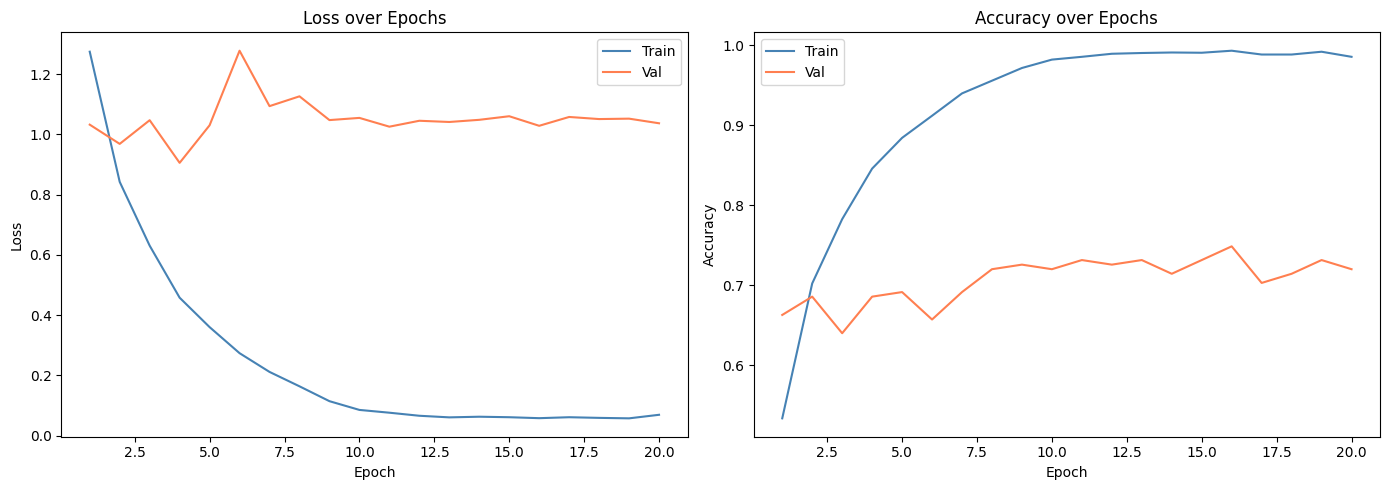

In [12]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, label='Train', color='steelblue')
ax1.plot(epochs, val_losses,   label='Val',   color='coral')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, train_accs, label='Train', color='steelblue')
ax2.plot(epochs, val_accs,   label='Val',   color='coral')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [13]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

# Metric 1: General accuracy
print(f'General Accuracy: {(all_preds == all_labels).mean():.4f} ({(all_preds == all_labels).mean()*100:.2f}%)')
print()

# Metrics 2 & 3: TP, FP, Precision by class
cm = confusion_matrix(all_labels, all_preds)
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
actual = cm.sum(axis=1)

print(f'{"Class":<20} {"TP":>6} {"FP":>6} {"Actual":>8} {"Precision":>10}')
print('-' * 55)
for i, cls in enumerate(class_names):
    precision = tp[i] / (tp[i] + fp[i]) if (tp[i] + fp[i]) > 0 else 0
    print(f'{cls:<20} {tp[i]:>6} {fp[i]:>6} {actual[i]:>8} {precision:>10.4f}')

General Accuracy: 0.7257 (72.57%)

Class                    TP     FP   Actual  Precision
-------------------------------------------------------
Amphibia                 17      7       26     0.7083
Arachnida                22      8       28     0.7333
Fungi                    18      2       29     0.9000
Insecta                  13     11       18     0.5417
Mammalia                 10      8       18     0.5556
Plantae                  30      4       33     0.8824
Reptilia                 17      8       23     0.6800


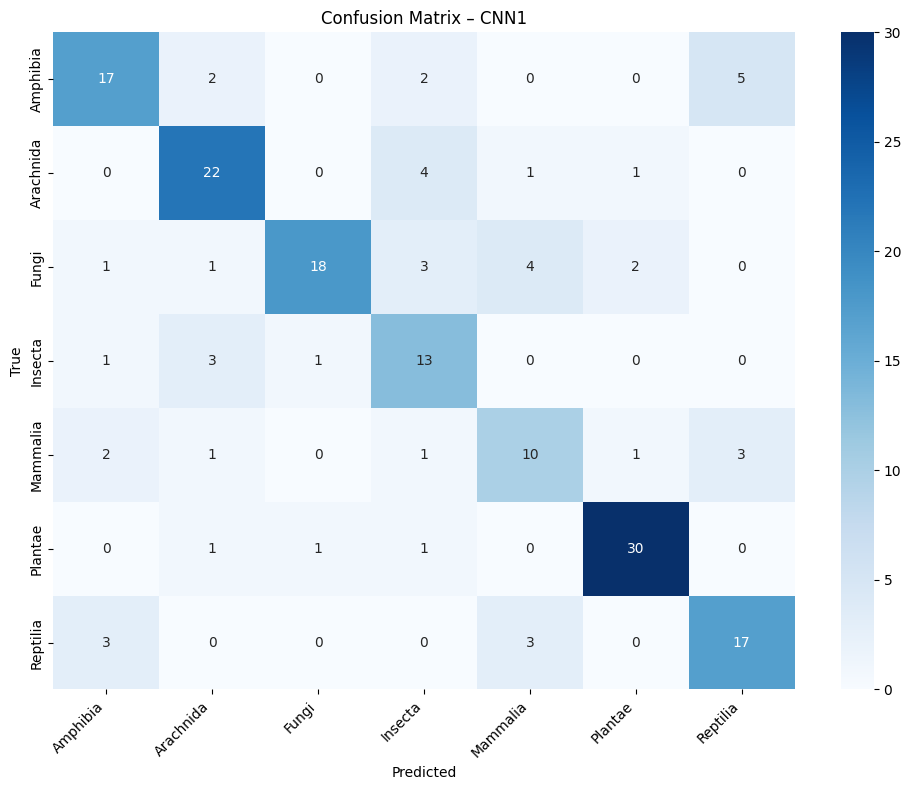

              precision    recall  f1-score   support

    Amphibia       0.71      0.65      0.68        26
   Arachnida       0.73      0.79      0.76        28
       Fungi       0.90      0.62      0.73        29
     Insecta       0.54      0.72      0.62        18
    Mammalia       0.56      0.56      0.56        18
     Plantae       0.88      0.91      0.90        33
    Reptilia       0.68      0.74      0.71        23

    accuracy                           0.73       175
   macro avg       0.71      0.71      0.71       175
weighted avg       0.74      0.73      0.73       175



In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix – CNN1')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## 10. Save to Google Drive

In [15]:
shutil.copy(best_model_path, '/content/drive/MyDrive/best_cnn1_model.pth')
print('Model saved to Drive!')

Model saved to Drive!
